### **Santander Customer Transaction Prediction**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
test = pd.read_csv('/content/test.csv')
train = pd.read_csv('/content/train.csv')

In [ ]:
print(test.shape)
print(train.shape)

(200000, 201)
(200000, 202)


In [ ]:
target_counts = train['target'].value_counts()
print(target_counts)

target
0    179902
1     20098
Name: count, dtype: int64


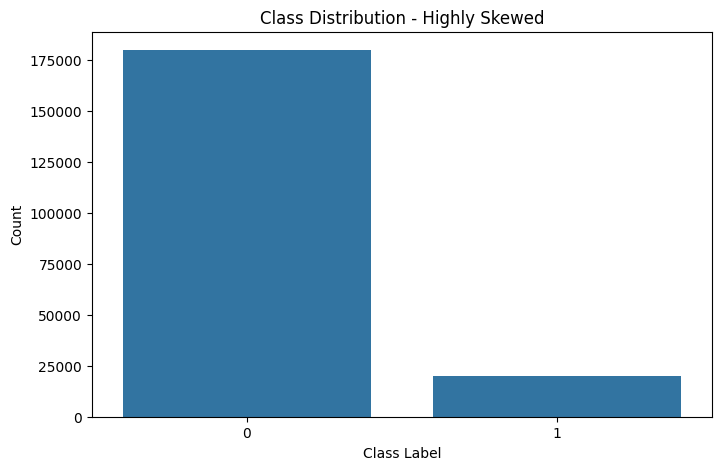

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Class Distribution - Highly Skewed')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

ROC-AUC Score (5-fold Stratified CV): 0.8595


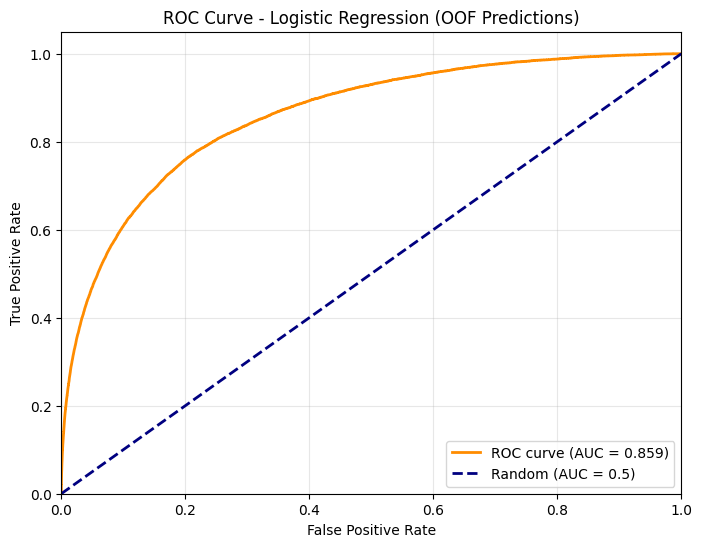

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Split into features and target (replace 'target' with your actual target column name)
X = train.drop(columns=['target', 'ID_code'])
y = train['target']

# Create pipeline with scaling and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Set up 5-fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold probability predictions
y_pred_proba = cross_val_predict(
    pipeline,
    X,
    y,
    cv=skf,
    method='predict_proba',
    n_jobs=-1
)

# Extract probabilities for positive class
y_pred_proba_positive = y_pred_proba[:, 1]

# Compute ROC-AUC score
roc_auc = roc_auc_score(y, y_pred_proba_positive)
print(f"ROC-AUC Score (5-fold Stratified CV): {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_proba_positive)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (OOF Predictions)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import lightgbm as lgb
import xgboost as xgb

# Store results for comparison
results = {}

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Load the training data
train = pd.read_csv('/content/train.csv')

# Function to get OOF predictions and ROC-AUC
def get_oof_predictions(model, X, y, cv, model_name):
    y_pred_proba = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )
    y_pred_proba_positive = y_pred_proba[:, 1]
    roc_auc = roc_auc_score(y, y_pred_proba_positive)
    results[model_name] = {'predictions': y_pred_proba_positive, 'roc_auc': roc_auc}
    return roc_auc

# Split into features and target (replace 'target' with your actual target column name)
X = train.drop(columns=['target', 'ID_code'])
y = train['target']

# Set up 5-fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LightGBM
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    verbose=-1
)
lgb_auc = get_oof_predictions(lgb_model, X, y, skf, 'LightGBM')
print(f"LightGBM ROC-AUC: {lgb_auc:.4f}")

# XGBoost
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_auc = get_oof_predictions(xgb_model, X, y, skf, 'XGBoost')
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

# Compare with Logistic Regression baseline (from Step 2)
# Assuming you have the logistic_regression_auc variable from previous step
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")

LightGBM ROC-AUC: 0.8652


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost ROC-AUC: 0.8560
Logistic Regression ROC-AUC: 0.8595


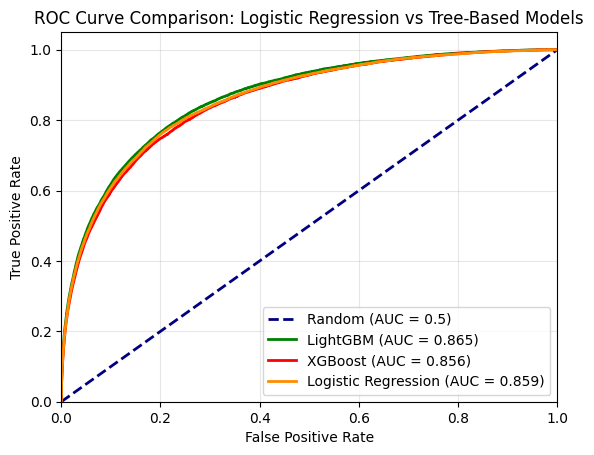


MODEL COMPARISON SUMMARY
Logistic Regression: 0.8595
LightGBM: 0.8652
XGBoost: 0.8560

LightGBM improvement over Logistic: +0.66%
XGBoost improvement over Logistic: -0.40%


In [ ]:
import matplotlib.pyplot as plt

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')

# Assuming results dictionary is populated with 'LightGBM' and 'XGBoost'
if 'LightGBM' in results:
    fpr_lgb, tpr_lgb, _ = roc_curve(y, results['LightGBM']['predictions'])
    plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM (AUC = {results["LightGBM"]["roc_auc"]:.3f})')

if 'XGBoost' in results:
    fpr_xgb, tpr_xgb, _ = roc_curve(y, results['XGBoost']['predictions'])
    plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {results["XGBoost"]["roc_auc"]:.3f})')

# Add Logistic Regression ROC curve using the 'roc_auc' variable from the previous step
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Logistic Regression vs Tree-Based Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print comparative results
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(f"Logistic Regression: {roc_auc:.4f}")
print(f"LightGBM: {lgb_auc:.4f}")
print(f"XGBoost: {xgb_auc:.4f}")

# Calculate improvement over baseline
lgb_improvement = ((lgb_auc - roc_auc) / roc_auc) * 100
xgb_improvement = ((xgb_auc - roc_auc) / roc_auc) * 100


print(f"\nLightGBM improvement over Logistic: {lgb_improvement:+.2f}%")
print(f"XGBoost improvement over Logistic: {xgb_improvement:+.2f}%")

Logistic Regression (0.8595 ROC-AUC) → Strong linear baseline.
LightGBM (0.8652) → Slightly better (+0.66%). Shows tree-based models capture extra structure.
XGBoost (0.8560) → Slightly worse than Logistic (–0.40%). Could be due to default parameters or overfitting.

In [ ]:
# Option 1: Reduce parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'num_leaves': [31, 63],
    # Remove subsample and colsample_bytree for now
}

# Option 2: Use RandomizedSearchCV instead
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    n_iter=50,  # Only try 50 random combinations
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  # Reduce to 3-fold
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Set up GridSearchCV with stratified k-fold
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Perform grid search
grid_search.fit(X, y)

# Print best results
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")
print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best ROC-AUC: 0.8724
Best parameters:
  learning_rate: 0.1
  max_depth: 5
  n_estimators: 200
  num_leaves: 63


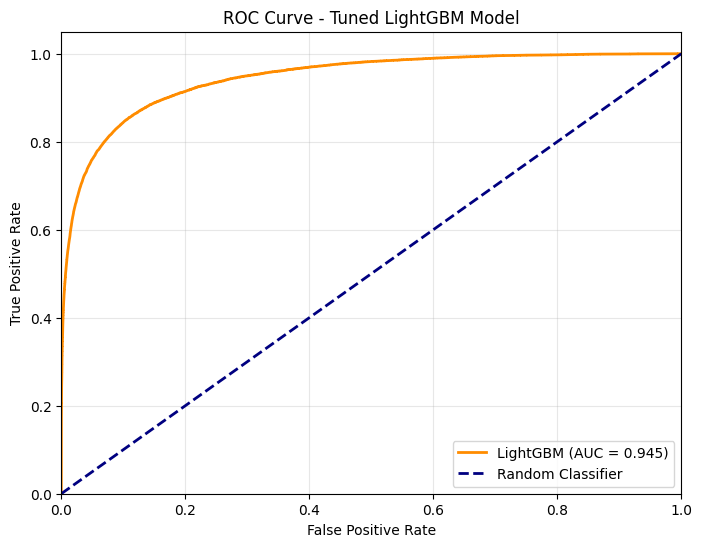

Tuned LightGBM ROC-AUC: 0.9449
Improvement over baseline: +9.21%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# Get best model from the search
best_model = grid_search.best_estimator_

# Make predictions with best model
y_pred_proba = best_model.predict_proba(X)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LightGBM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned LightGBM Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print comparison with baseline
print(f"Tuned LightGBM ROC-AUC: {roc_auc:.4f}")
print(f"Improvement over baseline: {(roc_auc - 0.8652) / 0.8652 * 100:+.2f}%")

In [ ]:
# Make predictions on the test data using the best model
test_predictions = best_model.predict_proba(test.drop(columns=['ID_code']))[:, 1]

# Create the submission DataFrame
submission = pd.DataFrame({
    'ID_code': test['ID_code'],
    'target': test_predictions
})

# Save the submission file
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")
print(submission.head())

Submission file created: submission.csv
  ID_code    target
0  test_0  0.087446
1  test_1  0.283433
2  test_2  0.139301
3  test_3  0.096521
4  test_4  0.057247
